In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per $10,000
- PTRATIO - pupil-teacher ratio by town
- B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT - % lower status of the population
- MEDV - Median value of owner-occupied homes in $1000's

In [7]:
column_names = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV",
]
df = pd.read_csv("housing.csv", header=None, delimiter=r"\s+", names=column_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Simple Linear Regression (LSTAT → MEDV):
Coefficient: -0.9665
Intercept: 34.8369
Mean Squared Error: 33.5195
R² Score: 0.5429


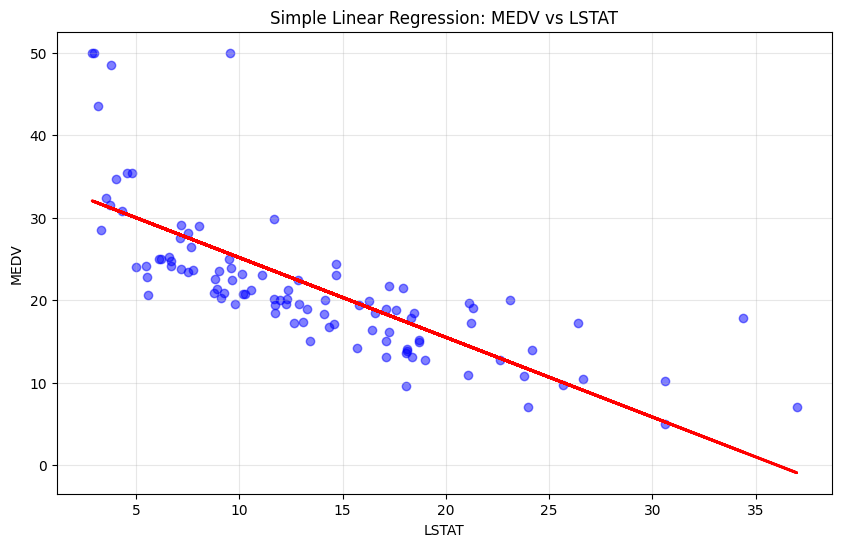

In [9]:
X_simple = df[["LSTAT"]].values
y = df["MEDV"].values

X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)

y_pred_simple = model_simple.predict(X_test_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression (LSTAT → MEDV):")
print(f"Coefficient: {model_simple.coef_[0]:.4f}")
print(f"Intercept: {model_simple.intercept_:.4f}")
print(f"Mean Squared Error: {mse_simple:.4f}")
print(f"R² Score: {r2_simple:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple, y_test, color="blue", alpha=0.5)
plt.plot(X_test_simple, y_pred_simple, color="red", linewidth=2)
plt.title("Simple Linear Regression: MEDV vs LSTAT")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.grid(True, alpha=0.3)
plt.show()

Polynomial Regression with Multiple Features:
Mean Squared Error: 14.5934
R² Score: 0.8010
Cross-validation RMSE: 6.3737 ± 1.9849


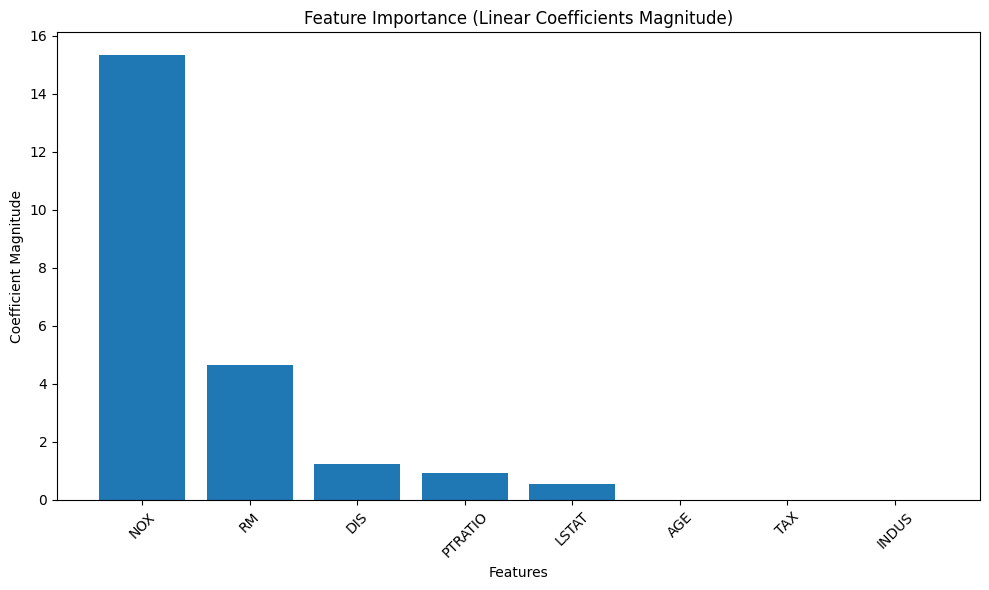

In [10]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

selected_features = ["LSTAT", "INDUS", "NOX", "PTRATIO", "RM", "TAX", "DIS", "AGE"]
X_multi = df[selected_features].values
y = df["MEDV"].values
X_train_multi, X_test_multi, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

poly_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression(),
)
poly_model.fit(X_train_multi, y_train)

y_pred_poly = poly_model.predict(X_test_multi)

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression with Multiple Features:")
print(f"Mean Squared Error: {mse_poly:.4f}")
print(f"R² Score: {r2_poly:.4f}")
cv_scores = cross_val_score(
    poly_model, X_multi, y, scoring="neg_mean_squared_error", cv=5
)
cv_rmse = np.sqrt(-cv_scores)

print(f"Cross-validation RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
linear_model = LinearRegression().fit(X_train_multi, y_train)
feature_importance = pd.DataFrame(
    {"Feature": selected_features, "Importance": np.abs(linear_model.coef_)}
)
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance (Linear Coefficients Magnitude)")
plt.xlabel("Features")
plt.ylabel("Coefficient Magnitude")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()